In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mehulkumar99/error-sql-prediction-csv/validation_predictions.csv
/kaggle/input/datasets/mehulkumar99/augmented-schema/schema_lookup_augmented.pkl
/kaggle/input/datasets/jeromeblanchet/yale-universitys-spider-10-nlp-dataset/spider/train_spider.json
/kaggle/input/datasets/jeromeblanchet/yale-universitys-spider-10-nlp-dataset/spider/train_others.json
/kaggle/input/datasets/jeromeblanchet/yale-universitys-spider-10-nlp-dataset/spider/dev_gold.sql
/kaggle/input/datasets/jeromeblanchet/yale-universitys-spider-10-nlp-dataset/spider/dev.json
/kaggle/input/datasets/jeromeblanchet/yale-universitys-spider-10-nlp-dataset/spider/README.txt
/kaggle/input/datasets/jeromeblanchet/yale-universitys-spider-10-nlp-dataset/spider/train_gold.sql
/kaggle/input/datasets/jeromeblanchet/yale-universitys-spider-10-nlp-dataset/spider/tables.json
/kaggle/input/datasets/jeromeblanchet/yale-universitys-spider-10-nlp-dataset/spider/database/solvency_ii/solvency_ii.sqlite
/kaggle/input/datasets/

In [2]:
import warnings
import transformers
transformers.logging.set_verbosity_error()
warnings.filterwarnings("ignore")

In [3]:
!pip install --upgrade huggingface_hub -q
!pip install "unsloth @ git+https://github.com/unslothai/unsloth.git" -q
!pip install "unsloth_zoo @ git+https://github.com/unslothai/unsloth-zoo.git" --force-reinstall --no-cache-dir -q
!pip install --no-deps "xformers<0.0.29" "trl<0.13.0" peft accelerate bitsandbytes -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 44.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 231.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 113.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 260.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 kB 149.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 152.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.6/660.6 kB 319.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 261.6 MB/s eta 0:00:0000:

In [4]:
! pip show unsloth

Name: unsloth
Version: 2026.4.8
Summary: 2-5X faster training, reinforcement learning & finetuning
Home-page: https://unsloth.ai
Author: Unsloth AI team
Author-email: info@unsloth.ai
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: nest-asyncio, pydantic, pyyaml, typer
Required-by: 


# Loading Model 

In [5]:
# CELL 2 - restart kernel after cell 1, then run this
import os
if not os.path.exists("/kaggle/working/llama-3-1-clean"):
    from huggingface_hub import snapshot_download
    snapshot_download(
        repo_id="unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",
        local_dir="/kaggle/working/llama-3-1-clean",
        local_dir_use_symlinks=False,
        resume_download=True
    )

In [6]:
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="/kaggle/working/llama-3-1-clean",
    max_seq_length=2048,
    dtype=None,
    load_in_4bit=True,
    device_map={"": 0}
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


[unsloth_zoo.log|WARNING]Unsloth: Could not patch trl.trainer.ppov2_trainer: Direct module loading failed for UnslothPPOv2Trainer: duplicate argument 'kwargs' in function definition (UnslothPPOv2Trainer.py, line 369)


==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [7]:
# Apply LoRA adapters
from peft import PeftModel
adapter_path = '/kaggle/input/notebooks/mehulkumar99/spider-question-to-sql-query/outputs/checkpoint-450'
model = PeftModel.from_pretrained(model, adapter_path)

print(f"Memory used: {model.get_memory_footprint()/1e9:.2f} GB")
model.print_trainable_parameters()

Memory used: 5.76 GB
trainable params: 0 || all params: 8,072,204,288 || trainable%: 0.0000


# Loading validation set

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset("spider")
# validation_df = pd.DataFrame(dataset['validation'])
train_df = pd.DataFrame(dataset['train'])


validation_df = pd.read_csv('/kaggle/input/datasets/mehulkumar99/error-sql-prediction-csv/validation_predictions.csv')
validation_df = validation_df.drop(columns=['query_toks', 'query_toks_no_value','question_toks',])
validation_df.head()
# validation_df.iloc[361]

README.md: 0.00B [00:00, ?B/s]

spider/train-00000-of-00001.parquet:   0%|          | 0.00/831k [00:00<?, ?B/s]

spider/validation-00000-of-00001.parquet:   0%|          | 0.00/126k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1034 [00:00<?, ? examples/s]

,db_id,query,question,schema,count_tables,predicted_sql,results
0,concert_singer,SELECT count(*) FROM singer,How many singers do we have?,"stadium : Stadium_ID (number) , Location (text...",4,SELECT count(*) FROM singer,correct
1,concert_singer,SELECT count(*) FROM singer,What is the total number of singers?,"stadium : Stadium_ID (number) , Location (text...",4,SELECT count(*) FROM singer,correct
2,concert_singer,"SELECT name , country , age FROM singer ORDE...","Show name, country, age for all singers ordere...","stadium : Stadium_ID (number) , Location (text...",4,"SELECT name, country, age FROM singer ORDER ...",correct
3,concert_singer,"SELECT name , country , age FROM singer ORDE...","What are the names, countries, and ages for ev...","stadium : Stadium_ID (number) , Location (text...",4,"SELECT name, country, age FROM singer ORDER ...",correct
4,concert_singer,"SELECT avg(age) , min(age) , max(age) FROM s...","What is the average, minimum, and maximum age ...","stadium : Stadium_ID (number) , Location (text...",4,"SELECT avg(age), min(age), max(age) FROM sin...",correct


In [9]:
wrong_data = validation_df.loc[validation_df['results'].isin(['error', 'wrong'])]
wrong_error_index = wrong_data.index.tolist()

In [10]:
len(wrong_error_index)

301

# Loading schema dataset

In [11]:
spider_tables = load_dataset("richardr1126/spider-schema", split="train")
df= pd.DataFrame(spider_tables)

print(spider_tables)

README.md: 0.00B [00:00, ?B/s]

spider_schema_rows_v2.json: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['db_id', 'Schema (values (type))', 'Primary Keys', 'Foreign Keys'],
    num_rows: 166
})


In [12]:
import pickle

# The path will now be in /kaggle/input/ instead of /kaggle/working/
file_path = '/kaggle/input/notebooks/mehulkumar99/agentic-loop/schema_lookup_augmented.pkl'

with open(file_path, 'rb') as f:
    schema_lookup = pickle.load(f)

print(f"Loaded schema for {len(schema_lookup)} databases.")

Loaded schema for 166 databases.


In [13]:
print(schema_lookup['concert_singer']['augmented_schema'])

# Table: stadium 
## Columns:
- Stadium_ID (number, PK) | e.g: [1, 2, 3]
- Location (text) | e.g: ['Raith Rovers', 'Ayr United', 'East Fife']
- Name (text) | e.g: ["Stark's Park", 'Somerset Park', 'Bayview Stadium']
- Capacity (number) | e.g: [10104, 11998, 2000]
- Highest (number) | e.g: [4812, 2363, 1980]
- Lowest (number) | e.g: [1294, 1057, 533]
- Average (number) | e.g: [2106, 1477, 864]

# Table: singer 
## Columns:
- Singer_ID (number, PK) | e.g: [1, 2, 3]
- Name (text) | e.g: ['Joe Sharp', 'Timbaland', 'Justin Brown']
- Country (text) | e.g: ['Netherlands', 'United States', 'France']
- Song_Name (text) | e.g: ['You', 'Dangerous', 'Hey Oh']
- Song_release_year (text) | e.g: ['1992', '2008', '2013']
- Age (number) | e.g: [52, 32, 29]
- Is_male (others) | e.g: ['F', 'T', 'T']

# Table: concert 
## Columns:
- concert_ID (number, PK) | e.g: [1, 2, 3]
- concert_Name (text) | e.g: ['Auditions', 'Super bootcamp', 'Home Visits']
- Theme (text) | e.g: ['Free choice', 'Free choice 2', 'Bl

## Understanding table Counts

Mean count (Per Database): 5.28
Mean count (Training Set): 6.04
Mean count (Validation Set): 4.52


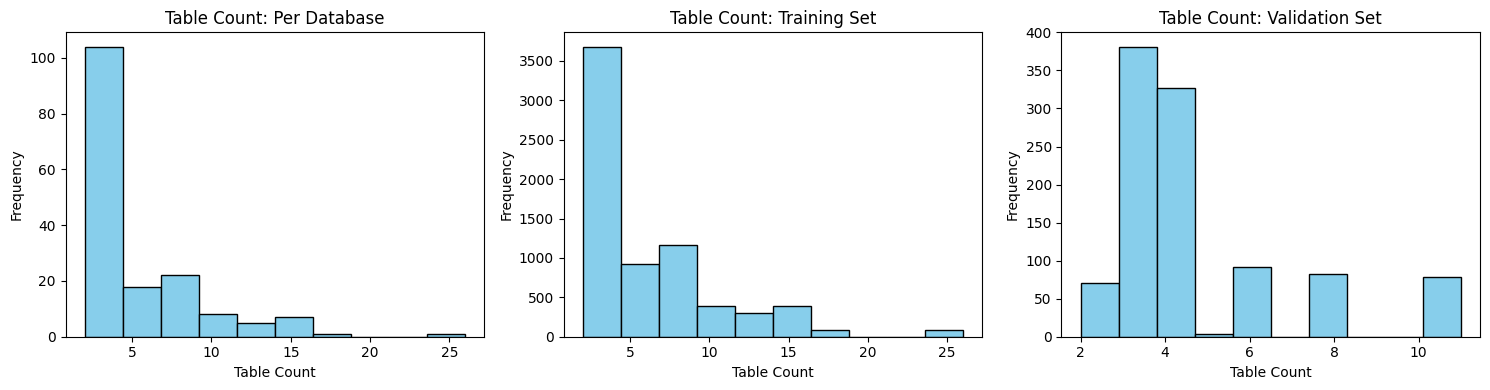

In [14]:
import numpy as np
def total_tables(schema):
    count = 0
    count = sum(1 for char in schema if char =='|')
    return count+1

import matplotlib.pyplot as plt
import numpy as np

# 1. Process the data
df['count_tables'] = df['Schema (values (type))'].apply(total_tables)
train_df['schema'] = train_df['db_id'].apply(lambda x: schema_lookup[x]['Schema (values (type))'])
train_df['count_tables'] = train_df['schema'].apply(total_tables)
validation_df['schema'] = validation_df['db_id'].apply(lambda x: schema_lookup[x]['Schema (values (type))'])
validation_df['count_tables'] = validation_df['schema'].apply(total_tables)

# 2. Define plotting data
datasets = [
    (df['count_tables'], 'Per Database'),
    (train_df['count_tables'], 'Training Set'),
    (validation_df['count_tables'], 'Validation Set')
]

# 3. Create subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (data, title) in zip(axes, datasets):
    ax.hist(data, bins=10, edgecolor='black', color='skyblue')
    ax.set_title(f'Table Count: {title}')
    ax.set_xlabel('Table Count')
    ax.set_ylabel('Frequency')
    print(f'Mean count ({title}): {np.mean(data):.2f}')

plt.tight_layout()
plt.show()

In [ ]:
print(schema_lookup['csu_1']['augmented_schema'])

# BUILDING PROMPT

In [15]:
def build_prompt( schema_lookup, index, dataset, inference = False, schema_type = None ):

    df = dataset
    prompt = ''

    db_id = df['db_id'][index]
    question = df['question'][index]

    if not schema_type:
        schema = schema_lookup[db_id]['format_schema']
    else:
        schema = schema_lookup[db_id]['augmented_schema']
    
    prompt = f"""<|start_header_id|>system<|end_header_id|>

Convert the natural language question to SQL using the schema below. Use SQLite syntax and SQLite functions only.<|eot_id|><|start_header_id|>user<|end_header_id|>

### Schema:
{schema}

### Question:
{question}"""

    if inference == True:
        text = prompt +  f"""<|eot_id|>""" + "<|start_header_id|>assistant<|end_header_id|>\n\n"
        return {'text': text}


    elif inference == False:
        query = df['query'][index]
        text = prompt+ f"""<|start_header_id|>assistant<|end_header_id|>

{query}<|eot_id|>"""
        
        return {'text':text}
    return{'text': prompt}



text = build_prompt( schema_lookup, index =779,dataset = validation_df, inference = True, schema_type = 1 )
print(text['text'])
    

<|start_header_id|>system<|end_header_id|>

Convert the natural language question to SQL using the schema below. Use SQLite syntax and SQLite functions only.<|eot_id|><|start_header_id|>user<|end_header_id|>

### Schema:
# Table: city 
## Columns:
- ID (number, PK) | e.g: [129, 1, 2]
- Name (text) | e.g: ['Kabul', 'Qandahar', 'Herat']
- CountryCode (text, FK -> country.Code) | e.g: ['ABW', 'AFG', 'AFG']
- District (text) | e.g: ['Kabol', 'Qandahar', 'Herat']
- Population (number) | e.g: [1780000, 237500, 186800]

# Table: sqlite_sequence 
## Columns:
- name (text) | e.g: ['city']
- seq (text) | e.g: [4079]

# Table: country 
## Columns:
- Code (text, PK) | e.g: ['ABW', 'AFG', 'AGO']
- Name (text) | e.g: ['Aruba', 'Afghanistan', 'Angola']
- Continent (text) | e.g: ['North America', 'Asia', 'Africa']
- Region (text) | e.g: ['Caribbean', 'Southern and Central Asia', 'Central Africa']
- SurfaceArea (number) | e.g: [193.0, 652090.0, 1246700.0]
- IndepYear (number) | e.g: [None, 1919, 1975]


## Filtering augmented tokens larger than 1950. 

In [17]:
#schema_lookup, index, dataset, last_exec_sql = None, error_msg = None, inference = False 
total = len(train_df)
lengths = []
for i in range(total):
    prompt = build_prompt( schema_lookup, index = i , dataset = train_df, inference = False, schema_type = 1 )['text']
    lengths.append(len(tokenizer(prompt)['input_ids']))

train_df['T'] = lengths

train_df = train_df.sort_values(by='T', ascending = False)
# & (validation_df['T']>1950)
filtered_df = train_df[(train_df['T']>2048) ]

# wrong_erro_df = filtered_df.loc[filtered_df['results'].isin(['error', 'wrong'])]
# filtered_sorted_df = filtered_df.sort_values(by='T', ascending = False)

# print(len(idx_prompt_limit_exceeded))
filtered_df.head()

,db_id,query,question,query_toks,query_toks_no_value,question_toks,schema,count_tables,T
3698,baseball_1,"SELECT T2.name_first , T2.name_last FROM sala...",What are the first name and last name of the p...,"[SELECT, T2.name_first, ,, T2.name_last, FROM,...","[select, t2, ., name_first, ,, t2, ., name_las...","[What, are, the, first, name, and, last, name,...","all_star : player_id (text) , year (number) , ...",26,7272
3697,baseball_1,"SELECT T2.name_first , T2.name_last FROM sala...",List players' first name and last name who rec...,"[SELECT, T2.name_first, ,, T2.name_last, FROM,...","[select, t2, ., name_first, ,, t2, ., name_las...","[List, players, ', first, name, and, last, nam...","all_star : player_id (text) , year (number) , ...",26,7268
3674,baseball_1,SELECT count(*) FROM ( SELECT * FROM postseaso...,How many times in total did the team Boston Re...,"[SELECT, count, (, *, ), FROM, (, SELECT, *, F...","[select, count, (, *, ), from, (, select, *, f...","[How, many, times, in, total, did, the, team, ...","all_star : player_id (text) , year (number) , ...",26,7216
3673,baseball_1,SELECT count(*) FROM ( SELECT * FROM postseaso...,What is the total number of postseason games t...,"[SELECT, count, (, *, ), FROM, (, SELECT, *, F...","[select, count, (, *, ), from, (, select, *, f...","[What, is, the, total, number, of, postseason,...","all_star : player_id (text) , year (number) , ...",26,7216
3636,baseball_1,"SELECT T1.name_first , T1.name_last , T1.play...",Which player has the most all star game experi...,"[SELECT, T1.name_first, ,, T1.name_last, ,, T1...","[select, t1, ., name_first, ,, t1, ., name_las...","[Which, player, has, the, most, all, star, gam...","all_star : player_id (text) , year (number) , ...",26,7210


In [18]:
len(filtered_df)

393

In [19]:
# Check the training set token distribution
total = len(train_df)
lengths = []
for i in range(total):
    prompt = build_prompt(schema_lookup, index=i, dataset=train_df, 
                         inference=False, schema_type=1)['text']
    lengths.append(len(tokenizer(prompt)['input_ids']))

train_df['token_count'] = lengths
print(f"Over 2048: {(train_df['token_count'] > 2048).sum()}")
print(f"Distribution:\n{train_df['token_count'].describe()}")

Over 2048: 393
Distribution:
count    7000.000000
mean      950.132571
std       884.946710
min       216.000000
25%       462.000000
50%       653.500000
75%      1230.250000
max      7272.000000
Name: token_count, dtype: float64


In [20]:
#schema_lookup, index, dataset, last_exec_sql = None, error_msg = None, inference = False 
total = len(validation_df)
lengths = []
for i in range(total):
    prompt = build_prompt( schema_lookup, index = i , dataset = validation_df, inference = True, schema_type = 1 )['text']
    lengths.append(len(tokenizer(prompt)['input_ids']))

validation_df['T'] = lengths
# & (validation_df['T']>1950)
filtered_df = validation_df[(validation_df['results'].isin(['error', 'wrong'])) ]

# wrong_erro_df = filtered_df.loc[filtered_df['results'].isin(['error', 'wrong'])]
filtered_sorted_df = filtered_df.sort_values(by='T', ascending = False)

# print(len(idx_prompt_limit_exceeded))
filtered_sorted_df.head()

,db_id,query,question,schema,count_tables,predicted_sql,results,T
541,student_transcripts_tracking,"SELECT T1.student_id , T1.first_name , T1.mi...",Which student has enrolled for the most times ...,"Addresses : address_id (number) , line_1 (text...",11,"SELECT T1.first_name, T1.middle_name, T1.las...",wrong,1568
922,dog_kennels,"SELECT professional_id , last_name , cell_nu...",Which professionals live in the state of India...,"Breeds : breed_code (text) , breed_name (text)...",8,"SELECT T1.last_name, T1.cell_number FROM prof...",wrong,1566
542,student_transcripts_tracking,"SELECT T1.student_id , T1.first_name , T1.mi...","What is the first, middle, and last name, alon...","Addresses : address_id (number) , line_1 (text...",11,"SELECT T1.first_name, T1.middle_name, T1.las...",wrong,1566
534,student_transcripts_tracking,"SELECT T1.first_name , T1.middle_name , T1.l...","What are the first, middle, and last names, al...","Addresses : address_id (number) , line_1 (text...",11,"SELECT T1.first_name, T1.middle_name, T1.las...",wrong,1564
923,dog_kennels,"SELECT professional_id , last_name , cell_nu...","Find the id, last name and cell phone of the p...","Breeds : breed_code (text) , breed_name (text)...",8,"SELECT T1.last_name, T1.cell_number FROM prof...",wrong,1562


In [21]:
import re
filtered_sorted_df['column_count'] = filtered_sorted_df['db_id'].apply(
    lambda db_id: sum(
        len(re.findall(r'^- ', block, re.MULTILINE))
        for block in re.split(r'(?=# Table:)', schema_lookup[db_id]['augmented_schema'].strip())
        if block.strip()
    )
)

filtered_sorted_df['table_count'] = filtered_sorted_df['db_id'].apply(
    lambda db_id: len(re.findall(r'^# Table:', schema_lookup[db_id]['augmented_schema'], re.MULTILINE))
)
filtered_sorted_df.to_csv("/kaggle/working/filtered_sorted_df.csv", index=False)

# filtered_sorted_df[['db_id', 'T', 'table_count', 'column_count']].head(20)

In [22]:
filtered_sorted_df.groupby('db_id').agg(
    example_count=('T', 'count'),
    avg_tokens=('T', 'mean'),
    max_tokens=('T', 'max'),
    table_count=('table_count', 'first'),
    column_count=('column_count', 'first')
).sort_values('avg_tokens', ascending=False).round(0)

,example_count,avg_tokens,max_tokens,table_count,column_count
db_id,,,,,
student_transcripts_tracking,26,1554.0,1568,11,56
dog_kennels,42,1553.0,1566,8,49
real_estate_properties,2,1082.0,1085,5,37
wta_1,32,1070.0,1079,3,43
tvshow,11,718.0,724,3,25
world_1,64,681.0,696,4,26
orchestra,3,630.0,632,4,23
car_1,48,628.0,639,6,23
concert_singer,3,558.0,560,4,21


In [23]:
print(len(filtered_sorted_df))
filtered_index = filtered_sorted_df.index.tolist()


301


# DATA LOADER PREP

In [24]:
from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding

# Step 1 — build prompts WITHOUT the answer (inference=True)
inference_texts = []
for i in filtered_index:
    result = build_prompt(schema_lookup, i, validation_df, inference=True, schema_type =1)
    inference_texts.append(result['text'])

# Step 2 — tokenize all prompts
tokenized = tokenizer(
    inference_texts,
    truncation=True,
    max_length=2048,
    padding=False,          # don't pad yet — DataLoader will handle per batch
    add_special_tokens= True,
    return_tensors=None,    # return list, not tensors
)

# Step 3 — build a simple dataset
from datasets import Dataset
inference_dataset = Dataset.from_dict({
    'input_ids': tokenized['input_ids'],
    'attention_mask': tokenized['attention_mask'],
})

tokenizer.padding_side = 'left'

# Step 4 — use DataCollatorWithPadding to batch and pad
collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True,
    return_tensors='pt',
)

dataloader = DataLoader(
    inference_dataset,
    batch_size=8,
    shuffle=False,           # keep order so predictions align with val_df rows
    collate_fn=collator,
)

In [ ]:
# from torch.utils.data import DataLoader
# from transformers import DataCollatorWithPadding

# # Step 1 — build prompts WITHOUT the answer (inference=True)
# inference_texts = []
# for i in range(len(validation_df)):
#     result = build_prompt(schema_lookup, i, validation_df, inference=True)
#     inference_texts.append(result['text'])

In [ ]:
# tokenizer.padding_side = 'left'
# tokenized = tokenizer(
#     inference_texts,
#     truncation=True,
#     max_length=2048,
#     padding=False,          # don't pad yet — DataLoader will handle per batch
#     add_special_tokens= True,
#     return_tensors=None,    # return list, not tensors
# )
# print(len(tokenized['input_ids']))
# print(list(tokenized.keys()))

Dataset.from_dict takes the keys from your dictionary (input_ids, attention_mask) and turns them into Columns. Each item in the list becomes a Row.

Row 1: input_ids for your first SQL prompt, attention_mask for your first SQL prompt.

Row 2: input_ids for your second SQL prompt

In [ ]:
# from datasets import Dataset
# inference_dataset = Dataset.from_dict({
#     'input_ids': tokenized['input_ids'],
#     'attention_mask': tokenized['attention_mask'],
# })
# print(inference_dataset.column_names)
# print(len(inference_dataset))

In [ ]:
# collator = DataCollatorWithPadding(
#     tokenizer=tokenizer,
#     padding=True,
#     return_tensors='pt',
# )
# print(collator.tokenizer.pad_token_id) # shows the pad_token_id used by the token

In [ ]:
# dataloader = DataLoader(
#     inference_dataset,
#     batch_size=16,
#     shuffle=False,           # keep order so predictions align with val_df rows
#     collate_fn=collator,
# )

In [25]:
# 1. Grab one batch
batch = next(iter(dataloader))

# 2. Get the pad token ID from your tokenizer
pad_id = tokenizer.pad_token_id

# 3. Inspect the first few tokens of the first row in the batch
# If it's Left Padding, the first few numbers should be the pad_id
print(f"Pad Token ID: {pad_id}")
print(f"First 10 tokens of row 0: {batch['input_ids'][1][:10].tolist()}")
print(f"Last 10 tokens of row 0:  {batch['input_ids'][1][-10:].tolist()}")

# 4. Logical check
is_left = batch['input_ids'][0][0] == pad_id
print(f"\nIs it Left Padded? {is_left}")

print(f'length of the first batch: {len(batch['input_ids'][1])}')

Pad Token ID: 128004
First 10 tokens of row 0: [128004, 128004, 128000, 128006, 9125, 128007, 271, 12281, 279, 5933]
Last 10 tokens of row 0:  [836, 323, 2849, 4641, 13, 128009, 128006, 78191, 128007, 271]

Is it Left Padded? False
length of the first batch: 1568


# GENERATION

In [26]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

In [27]:
import time
torch.cuda.reset_peak_memory_stats()

start = time.time()
batch = next(iter(dataloader))
input_ids = batch['input_ids'].to(model.device)
attention_mask = batch['attention_mask'].to(model.device)

with torch.no_grad():
    outputs = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=128,
        do_sample=False,
        use_cache=True,
        eos_token_id=tokenizer.convert_tokens_to_ids("<|eot_id|>"),
        pad_token_id=tokenizer.pad_token_id,
    )

elapsed = time.time() - start
peak = torch.cuda.max_memory_allocated() / 1024**3
print(f"Time: {elapsed:.1f}s, Peak memory: {peak:.2f}GB")

Time: 52.0s, Peak memory: 10.01GB


In [28]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

In [29]:
# from unsloth import FastLanguageModel

# FastLanguageModel.for_inference(model)  # unsloth inference mode — 2x faster

from tqdm.auto import tqdm
predictions = []

model.eval()
for batch in tqdm(dataloader, desc = 'Generating'):
    input_ids      = batch['input_ids'].to(model.device)
    attention_mask = batch['attention_mask'].to(model.device)

    # GREEDY SEARCH
    with torch.no_grad():
        outputs = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=128,
        do_sample=False,        # greedy
        use_cache=True,         # works fine with greedy
        eos_token_id=tokenizer.convert_tokens_to_ids("<|eot_id|>"),
        pad_token_id=tokenizer.pad_token_id,
        # temperature=0.2, # Very close to greedy but allows slight variation
        # top_p=0.95,
    )

    for i, output in enumerate(outputs):
        # print(output)
        actual_prompt_len = batch['attention_mask'][i].sum().item()
        generated = output[batch['input_ids'].shape[1]:]
        sql = tokenizer.decode(generated, skip_special_tokens=True).strip()
        if sql.startswith("assistant"):
            sql = sql[len("assistant"):].strip()
        predictions.append(sql)


print(predictions[:14])

Generating:   0%|          | 0/38 [00:00<?, ?it/s]

['SELECT T1.student_id,  T1.first_name,  T1.middle_name,  T1.last_name,  count(*),  T1.student_id FROM Students AS T1 JOIN Student_Enrolment AS T2 ON T1.student_id  =  T2.student_id GROUP BY T1.student_id ORDER BY count(*) DESC LIMIT 1', 'SELECT T1.professional_id,  T1.last_name,  T1.cell_number FROM Professionals AS T1 JOIN Treatments AS T2 ON T1.professional_id  =  T2.professional_id GROUP BY T2.professional_id HAVING count(*)  >  2 UNION SELECT professional_id,  last_name,  cell_number FROM Professionals WHERE state  =  "Indiana"', 'SELECT T1.first_name,  T1.middle_name,  T1.last_name,  T1.student_id,  count(*) FROM Students AS T1 JOIN Student_Enrolment AS T2 ON T1.student_id  =  T2.student_id GROUP BY T1.student_id ORDER BY count(*) DESC LIMIT 1', 'SELECT T1.first_name,  T1.middle_name,  T1.last_name,  T1.student_id FROM Students AS T1 JOIN Student_Enrolment AS T2 ON T1.student_id  =  T2.student_id GROUP BY T2.degree_program_id HAVING count(*)  =  2', 'SELECT T1.professional_id,  T

In [30]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

In [31]:
import json
with open("/kaggle/working/predictions.json", "w") as f:
    json.dump(predictions, f)

In [32]:
validation_df['new_pred_sql'] = validation_df['predicted_sql']

# Assuming 'df' is your DataFrame and 'indices' is your list
validation_df.loc[ filtered_index, 'new_pred_sql'] = predictions 


In [33]:
index = 767
print(validation_df['predicted_sql'].iloc[index])
print(validation_df['new_pred_sql'].iloc[index])

SELECT sum(T1.population) FROM country AS T1 JOIN countrylanguage AS T2 ON T1.code  =  T2.countrycode WHERE T2.language !=  "english"
SELECT sum(T1.population) FROM country AS T1 JOIN countrylanguage AS T2 ON T1.code  =  T2.countrycode WHERE T2.language!=  'English'


In [34]:

filtered_index

[541,
 922,
 542,
 534,
 923,
 583,
 533,
 549,
 584,
 572,
 941,
 940,
 937,
 956,
 945,
 936,
 925,
 571,
 932,
 550,
 928,
 963,
 944,
 929,
 924,
 998,
 958,
 962,
 927,
 950,
 539,
 942,
 535,
 536,
 930,
 573,
 951,
 943,
 954,
 529,
 957,
 926,
 576,
 561,
 999,
 955,
 959,
 938,
 939,
 526,
 920,
 531,
 554,
 961,
 547,
 575,
 948,
 548,
 997,
 996,
 921,
 960,
 967,
 992,
 980,
 578,
 511,
 581,
 1033,
 464,
 1032,
 452,
 465,
 466,
 448,
 459,
 447,
 467,
 458,
 455,
 468,
 460,
 485,
 463,
 472,
 483,
 484,
 486,
 456,
 470,
 471,
 469,
 440,
 479,
 480,
 489,
 439,
 490,
 481,
 482,
 473,
 474,
 610,
 632,
 606,
 631,
 642,
 597,
 598,
 627,
 617,
 587,
 628,
 799,
 797,
 817,
 811,
 810,
 793,
 798,
 796,
 792,
 769,
 782,
 789,
 783,
 788,
 794,
 795,
 787,
 818,
 777,
 781,
 820,
 766,
 785,
 768,
 764,
 707,
 731,
 765,
 790,
 775,
 780,
 816,
 772,
 748,
 757,
 741,
 740,
 821,
 819,
 784,
 786,
 778,
 719,
 749,
 773,
 745,
 779,
 767,
 717,
 747,
 755,
 746,
 814,
 8

In [35]:
validation_df.head(3)

,db_id,query,question,schema,count_tables,predicted_sql,results,T,new_pred_sql
0,concert_singer,SELECT count(*) FROM singer,How many singers do we have?,"stadium : Stadium_ID (number) , Location (text...",4,SELECT count(*) FROM singer,correct,551,SELECT count(*) FROM singer
1,concert_singer,SELECT count(*) FROM singer,What is the total number of singers?,"stadium : Stadium_ID (number) , Location (text...",4,SELECT count(*) FROM singer,correct,552,SELECT count(*) FROM singer
2,concert_singer,"SELECT name , country , age FROM singer ORDE...","Show name, country, age for all singers ordere...","stadium : Stadium_ID (number) , Location (text...",4,"SELECT name, country, age FROM singer ORDER ...",correct,563,"SELECT name, country, age FROM singer ORDER ..."


In [36]:
# # Save predictions
# import pandas as pd
# validation_df['predicted_sql'] = predictions
validation_df.to_csv("/kaggle/working/new_validation_predictions.csv", index=False)

# # Save model adapter too if not already saved
# model.save_pretrained("/kaggle/working/final_adapter")
# tokenizer.save_pretrained("/kaggle/working/final_adapter")

In [37]:
# schema_table= pd.DataFrame(spider_tables)
# schema_table['format_schema'] = df['db_id'].apply(format_schema)

In [38]:
import pandas as pd
validation_df = pd.read_csv('/kaggle/working/new_validation_predictions.csv')
validation_df.head(3)

,db_id,query,question,schema,count_tables,predicted_sql,results,T,new_pred_sql
0,concert_singer,SELECT count(*) FROM singer,How many singers do we have?,"stadium : Stadium_ID (number) , Location (text...",4,SELECT count(*) FROM singer,correct,551,SELECT count(*) FROM singer
1,concert_singer,SELECT count(*) FROM singer,What is the total number of singers?,"stadium : Stadium_ID (number) , Location (text...",4,SELECT count(*) FROM singer,correct,552,SELECT count(*) FROM singer
2,concert_singer,"SELECT name , country , age FROM singer ORDE...","Show name, country, age for all singers ordere...","stadium : Stadium_ID (number) , Location (text...",4,"SELECT name, country, age FROM singer ORDER ...",correct,563,"SELECT name, country, age FROM singer ORDER ..."


In [39]:
validation_df['results'].value_counts()

results
correct    733
wrong      251
error       50
Name: count, dtype: int64

# EXECUTING SQL

In [40]:
import os
import sqlite3

KAGGLE_DB_DIR = '/kaggle/input/datasets/jeromeblanchet/yale-universitys-spider-10-nlp-dataset/spider/database'
def execute_sql(sql, db_id, db_dir = KAGGLE_DB_DIR ):
    
    """Execute SQL against SQLite DB, return result set or None on error."""
    db_path = os.path.join(db_dir, db_id, f"{db_id}.sqlite")

    # CRITICAL: Check if the file actually exists before connecting
    if not os.path.exists(db_path):
        print(f"Warning: Database file not found at {db_path}")
        return None
    try:
        # 'mode=ro' tells SQLite to open it in Read-Only mode
        conn = sqlite3.connect(f"file:{db_path}?mode=ro", uri=True)
        cursor = conn.cursor()
        cursor.execute(sql)
        result = cursor.fetchall()
        conn.close()
        return result
    # except Exception as e:
    #     return None   # invalid SQL
    except sqlite3.Error as e:
        # This will return the specific SQLite error message (e.g., "no such column: name")
        print(f"SQL Error on {db_id}: {e}")
        return str(e)
    except Exception as e:
        # This catches other issues (like file path errors)
        print(f"General Error: {e}")
        return None
    
sql = 'SELECT T1.Continent,  count(*),  T2.ContinentId FROM continents AS T1 JOIN countries AS T2 ON T1.ContId  =  T2.Continent GROUP BY T2.ContinentId'
result = execute_sql(sql, db_id = 'car_1')
print(result)

SQL Error on car_1: no such column: T2.ContinentId
no such column: T2.ContinentId


In [41]:
import os
import sqlite3
import pandas as pd

def normalize_df(df):
    """Sort columns alphabetically and rows by all columns for order-invariant comparison."""
    df = df.copy()
    # Normalize column names to lowercase
    df.columns = [c.lower().strip() for c in df.columns]
    # Sort columns alphabetically
    df = df.reindex(sorted(df.columns), axis=1)
    # Sort rows by all columns (converts to str to handle mixed types)
    df = df.apply(lambda col: col.astype(str).str.strip().str.lower())
    df = df.sort_values(by=list(df.columns)).reset_index(drop=True)
    return df

def execution_match(pred_df, gold_df):
    """Returns True if pred and gold have same content regardless of column/row order."""
    try:
        pred_norm = normalize_df(pred_df)
        gold_norm = normalize_df(gold_df)

        # print(pred_norm)
        # print(gold_norm)
        
        if pred_norm.equals(gold_norm):
            return 'correct'
    except Exception:
        return 'wrong'



def evaluate_pair(db_path, pred_sql, gold_sql):
    conn = sqlite3.connect(db_path)
    try:
        pred_df = pd.read_sql_query(pred_sql, conn)
        gold_df = pd.read_sql_query(gold_sql, conn)
        return execution_match(pred_df, gold_df)
    except Exception as e:
        return 'error'  # SQL error = wrong
    finally:
        conn.close()

# pred_sql = 'SELECT T1.Continent,  count(*),  T1.ContId FROM continents AS T1 JOIN countries AS T2 ON T1.ContId  =  T2.Continent GROUP BY T1.ContId'
# gold_sql = 'SELECT T1.ContId ,  T1.Continent ,  count(*) FROM CONTINENTS AS T1 JOIN COUNTRIES AS T2 ON T1.ContId  =  T2.Continent GROUP BY T1.ContId'

KAGGLE_DB_DIR = '/kaggle/input/datasets/jeromeblanchet/yale-universitys-spider-10-nlp-dataset/spider/database'
db_dir = KAGGLE_DB_DIR

i = 0

pred_sql = validation_df['new_pred_sql'].iloc[i]
gold_sql = validation_df['query'].iloc[i]
db_id = validation_df['db_id'].iloc[i]

db_path = db_path = os.path.join(db_dir, db_id, f"{db_id}.sqlite")

results = evaluate_pair(db_path, pred_sql, gold_sql)
results

'correct'

In [42]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import Counter
import threading
from tqdm.auto import tqdm

def execution_match(pred_df, gold_df):
    pred_norm = normalize_df(pred_df)
    gold_norm = normalize_df(gold_df)
    return 'correct' if pred_norm.equals(gold_norm) else 'wrong'

def evaluate_pair(db_path, pred_sql, gold_sql):
    conn = sqlite3.connect(db_path, check_same_thread=False, timeout=10)
    try:
        pred_df = pd.read_sql_query(pred_sql, conn)
        gold_df = pd.read_sql_query(gold_sql, conn)
        return execution_match(pred_df, gold_df)
    except Exception:
        return 'error'
    finally:
        conn.close()

def evaluate_single(args):
    i, pred_sql, gold_sql, db_id = args
    db_path = os.path.join(db_dir, db_id, f"{db_id}.sqlite")
    status = evaluate_pair(db_path, pred_sql, gold_sql)
    return i, status

def execution_accuracy_parallel(validation_df, max_workers=4):
    total = len(validation_df)
    args_list = [
        (i,
         validation_df['new_pred_sql'].iloc[i],
         validation_df['query'].iloc[i],
         validation_df['db_id'].iloc[i])
        for i in range(total)
    ]

    results = [None] * total

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(evaluate_single, args): args[0] for args in args_list}
        for future in tqdm(as_completed(futures), total=total, desc="Evaluating"):
            i = futures[future]
            try:
                i, status = future.result()
                results[i] = status
            except Exception as e:
                results[i] = 'error'

    correct  = sum(1 for r in results if r == 'correct')
    errors   = sum(1 for r in results if r == 'error')
    wrong    = sum(1 for r in results if r == 'wrong')
    accuracy = correct / total

    print(f"Execution Accuracy : {accuracy:.4f} ({correct}/{total})")
    print(f"Wrong              : {wrong}/{total}")
    print(f"Invalid SQL errors : {errors}/{total}")
    return accuracy, results

In [43]:
# Step 2 — evaluation (CPU, parallelized, no GPU needed)
accuracy, results = execution_accuracy_parallel(validation_df, max_workers=4)


Evaluating:   0%|          | 0/1034 [00:00<?, ?it/s]

Execution Accuracy : 0.8095 (837/1034)
Wrong              : 161/1034
Invalid SQL errors : 36/1034


In [44]:
error = sum(1 for i, result in enumerate(results) if result == 'error')
error

36

In [45]:
validation_df['results'] = results


In [46]:
validation_df.to_csv("/kaggle/working/newest_validation_predictions.csv", index=False)

In [47]:
validation_df['results'].value_counts()

results
correct    837
wrong      161
error       36
Name: count, dtype: int64